In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

# --------------------------------------------------
# Paths
# --------------------------------------------------

DATA_DIR = Path(
    "/Users/neda/Documents/Projects/2027_ICPhS (2)/data"
)

In [24]:
# Hand-crafted representations
df_rhythm = pd.read_csv(
    DATA_DIR / "df_rhythm_persian.csv"
)

df_egemaps = pd.read_csv(
    DATA_DIR / "persian_egemaps_features.csv"
)

# Learned representation: XLSR-53, layer 3
df_xlsr_L03 = pd.read_csv( DATA_DIR / "persian_wav2vec2_xlsr53_L03.csv")

In [25]:
# --------------------------------------------------
# Harmonize speaker IDs
# --------------------------------------------------

# Rhythm already uses IDs such as P01, P02, ..., P30
df_rhythm["speaker_id"] = df_rhythm["Speaker"]

# eGeMAPS: extract final two digits from IDs such as P_1984_F_22
df_egemaps["speaker_id"] = (
    "P" + df_egemaps["speaker"].str.extract(r"_(\d{2})$")[0]
)

# XLSR L03: same speaker-ID structure as eGeMAPS
df_xlsr_L03["speaker_id"] = (
    "P" + df_xlsr_L03["speaker"].str.extract(r"_(\d{2})$")[0]
)


# --------------------------------------------------
# Define metadata columns
# --------------------------------------------------

rhythm_metadata = [
    "File_Name",
    "Language",
    "Speaker",
    "Year_of_Birth",
    "Age",
    "Gender",
    "ID",
    "Task",
    "speaker_id",
]

egemaps_metadata = [
    "speaker",
    "task",
    "file",
    "feature_set",
    "feature_level",
    "speaker_id",
]

xlsr_metadata = [
    "file",
    "start",
    "end",
    "speaker",
    "task",
    "speaker_id",
]


# --------------------------------------------------
# Define feature columns
# --------------------------------------------------

rhythm_features = [
    col for col in df_rhythm.columns
    if col not in rhythm_metadata
]

egemaps_features = [
    col for col in df_egemaps.columns
    if col not in egemaps_metadata
]

# Explicitly select the learned embedding dimensions.
# This is safer than simply taking every non-metadata column.
xlsr_features = [
    col for col in df_xlsr_L03.columns
    if col.startswith("feat_")
]


# --------------------------------------------------
# Check feature dimensions
# --------------------------------------------------

print("Feature dimensions")
print("------------------")
print(f"Rhythm:   {len(rhythm_features)}")
print(f"eGeMAPS:  {len(egemaps_features)}")
print(f"XLSR L03: {len(xlsr_features)}")

Feature dimensions
------------------
Rhythm:   28
eGeMAPS:  88
XLSR L03: 1024


In [26]:
print(df_rhythm[["speaker_id", "Task"]].head())
print(df_egemaps[["speaker_id", "task"]].head())

# Replace these two names below if the XLSR metadata uses different names
print(df_xlsr_L03.head())

  speaker_id  Task
0        P22  m(f)
1        P22  m(i)
2        P22  r(f)
3        P22  r(i)
4        P22   con
  speaker_id  task
0        P22   con
1        P22  m(f)
2        P22  m(i)
3        P22   pic
4        P22  r(f)
                                                file   start  \
0  /data/fburkhardt/papers/ICPHS-2027/data/persia...  0 days   
1  /data/fburkhardt/papers/ICPHS-2027/data/persia...  0 days   
2  /data/fburkhardt/papers/ICPHS-2027/data/persia...  0 days   
3  /data/fburkhardt/papers/ICPHS-2027/data/persia...  0 days   
4  /data/fburkhardt/papers/ICPHS-2027/data/persia...  0 days   

                         end      speaker  task    feat_0    feat_1    feat_2  \
0  0 days 00:01:35.485437500  P_1984_F_22   con -0.012352  0.010579 -0.034666   
1     0 days 00:01:09.097250  P_1984_F_22  m(f) -0.015248  0.044873 -0.032552   
2     0 days 00:01:12.835250  P_1984_F_22  m(i) -0.012136  0.045118 -0.030802   
3     0 days 00:02:14.834000  P_1984_F_22   pic -0.006711  0.01

# PCA

Run PCA for all three representations

In [41]:
# --------------------------------------------------
# PCA function: retain at least 80% of variance
# --------------------------------------------------

def fit_pca(df, feature_cols, variance_threshold=0.80):
    """
    Standardize features and perform PCA.

    Retains the minimum number of principal components
    needed to explain at least the specified proportion
    of total variance.
    """

    X = df[feature_cols].astype(float).values

    # Z-standardization
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Full PCA
    pca = PCA()
    scores_all = pca.fit_transform(X_scaled)

    # Cumulative explained variance
    cumulative_variance = np.cumsum(
        pca.explained_variance_ratio_
    )

    # Minimum number of PCs needed to reach threshold
    n_retained = (
        np.searchsorted(
            cumulative_variance,
            variance_threshold
        ) + 1
    )

    # Actual variance explained by retained PCs
    explained_variance = cumulative_variance[
        n_retained - 1
    ]

    # Retained PC scores
    scores = pd.DataFrame(
        scores_all[:, :n_retained],
        columns=[
            f"PC{i+1}"
            for i in range(n_retained)
        ],
        index=df.index
    )

    return {
        "scaler": scaler,
        "pca": pca,
        "scores": scores,
        "eigenvalues": pca.explained_variance_,
        "n_retained": n_retained,
        "explained_variance": explained_variance,
        "variance_threshold": variance_threshold
    }

In [42]:
rhythm_pca = fit_pca(
    df_rhythm,
    rhythm_features
)

egemaps_pca = fit_pca(
    df_egemaps,
    egemaps_features
)

xlsr_L03_pca = fit_pca(
    df_xlsr_L03,
    xlsr_features
)

Inspect the PCA results

In [43]:
pca_summary = pd.DataFrame({
    "representation": [
        "Rhythm",
        "eGeMAPS",
        "XLSR L03"
    ],

    "original_dimensions": [
        len(rhythm_features),
        len(egemaps_features),
        len(xlsr_features)
    ],

    "retained_PCs": [
        rhythm_pca["n_retained"],
        egemaps_pca["n_retained"],
        xlsr_L03_pca["n_retained"]
    ],

    "variance_explained": [
        rhythm_pca["explained_variance"],
        egemaps_pca["explained_variance"],
        xlsr_L03_pca["explained_variance"]
    ]
})

pca_summary["variance_explained"] *= 100

print(pca_summary)

  representation  original_dimensions  retained_PCs  variance_explained
0         Rhythm                   28             4           80.635615
1        eGeMAPS                   88            11           81.216458
2       XLSR L03                 1024            19           80.724229


# BETWEEN-SPEAKER RSA

Function to construct a speaker RDM

In [44]:
def speaker_rdm(
    df,
    pca_result,
    speaker_col,
    task_col,
    k=None
):
    """
    Construct a speaker-by-speaker representational
    dissimilarity matrix (RDM).

    1. Use retained PCA scores.
    2. Center observations within task.
    3. Calculate one centroid per speaker.
    4. Calculate pairwise Euclidean distances
       among speaker centroids.
    """

    if k is None:
        k = pca_result["n_retained"]

    pc_cols = [
        f"PC{i+1}"
        for i in range(k)
    ]

    scores = pca_result["scores"][pc_cols].copy()

    scores["speaker"] = df[speaker_col].values
    scores["task"] = df[task_col].values

    # -------------------------
    # Task centering
    # -------------------------

    task_means = (
        scores
        .groupby("task")[pc_cols]
        .transform("mean")
    )

    scores[pc_cols] = (
        scores[pc_cols] - task_means
    )

    # -------------------------
    # Speaker centroids
    # -------------------------

    speaker_centroids = (
        scores
        .groupby("speaker")[pc_cols]
        .mean()
        .sort_index()
    )

    # -------------------------
    # Pairwise distances
    # -------------------------

    distances = squareform(
        pdist(
            speaker_centroids.values,
            metric="euclidean"
        )
    )

    rdm = pd.DataFrame(
        distances,
        index=speaker_centroids.index,
        columns=speaker_centroids.index
    )

    return speaker_centroids, rdm

In [45]:
rhythm_centroids, rhythm_rdm = speaker_rdm(
    df=df_rhythm,
    pca_result=rhythm_pca,
    speaker_col="speaker_id",
    task_col="Task"
)

egemaps_centroids, egemaps_rdm = speaker_rdm(
    df=df_egemaps,
    pca_result=egemaps_pca,
    speaker_col="speaker_id",
    task_col="task"
)

xlsr_L03_centroids, xlsr_L03_rdm = speaker_rdm(
    df=df_xlsr_L03,
    pca_result=xlsr_L03_pca,
    speaker_col="speaker_id",
    task_col="task"
)

Check the RDMs

In [32]:
print("Rhythm:", rhythm_rdm.shape)
print("eGeMAPS:", egemaps_rdm.shape)
print("XLSR L03:", xlsr_L03_rdm.shape)

print("\nRhythm:")
print(rhythm_rdm.iloc[:5, :5])

Rhythm: (30, 30)
eGeMAPS: (30, 30)
XLSR L03: (30, 30)

Rhythm:
speaker       P01       P02       P03       P04       P05
speaker                                                  
P01      0.000000  4.546270  3.679935  5.045483  4.498393
P02      4.546270  0.000000  4.486277  4.264489  3.623554
P03      3.679935  4.486277  0.000000  2.776363  3.171102
P04      5.045483  4.264489  2.776363  0.000000  2.940229
P05      4.498393  3.623554  3.171102  2.940229  0.000000


RSA COMPARISON

Function for comparing two RDMs

This calculates Spearman correlation across the 435 unique speaker pairs.

In [46]:
def compare_rdms(
    rdm1,
    rdm2,
    n_permutations=10000,
    seed=42
):
    """
    Compare two speaker RDMs using Spearman correlation
    and a speaker-label permutation test.
    """

    # Same speakers in both matrices
    common = sorted(
        set(rdm1.index) &
        set(rdm2.index)
    )

    A = rdm1.loc[common, common].values
    B = rdm2.loc[common, common].values

    n = len(common)

    # Upper triangle:
    # 30 speakers -> 435 unique pairs
    upper = np.triu_indices(n, k=1)

    x = A[upper]
    y = B[upper]

    # -------------------------
    # Observed RSA
    # -------------------------

    observed_rho, _ = spearmanr(x, y)

    # -------------------------
    # Permutation inference
    # -------------------------

    rng = np.random.default_rng(seed)

    permutation_rhos = np.empty(
        n_permutations
    )

    for i in range(n_permutations):

        perm = rng.permutation(n)

        # Permute rows and columns together
        B_perm = B[np.ix_(perm, perm)]

        y_perm = B_perm[upper]

        permutation_rhos[i], _ = spearmanr(
            x,
            y_perm
        )

    # Two-sided permutation p-value
    p_value = (
        np.sum(
            np.abs(permutation_rhos)
            >= np.abs(observed_rho)
        ) + 1
    ) / (n_permutations + 1)

    return {
        "rho": observed_rho,
        "p": p_value,
        "n_speakers": n,
        "n_pairs": len(x),
        "permutation_rhos": permutation_rhos
    }

Rhythm vs eGeMAPS

In [47]:
rsa_rhythm_egemaps = compare_rdms(
    rhythm_rdm,
    egemaps_rdm,
    n_permutations=10000,
    seed=42
)

print("RHYTHM vs EGEMAPS")
print(
    f"RSA rho = "
    f"{rsa_rhythm_egemaps['rho']:.3f}"
)
print(
    f"Permutation p = "
    f"{rsa_rhythm_egemaps['p']:.4f}"
)
print(
    f"Speaker pairs = "
    f"{rsa_rhythm_egemaps['n_pairs']}"
)

RHYTHM vs EGEMAPS
RSA rho = 0.434
Permutation p = 0.0001
Speaker pairs = 435


Rhythm vs XLSR L03

In [48]:
rsa_rhythm_xlsr_L03 = compare_rdms(
    rhythm_rdm,
    xlsr_L03_rdm,
    n_permutations=10000,
    seed=42
)

print("RHYTHM vs XLSR L03")
print(
    f"RSA rho = "
    f"{rsa_rhythm_xlsr_L03['rho']:.3f}"
)
print(
    f"Permutation p = "
    f"{rsa_rhythm_xlsr_L03['p']:.4f}"
)

RHYTHM vs XLSR L03
RSA rho = 0.410
Permutation p = 0.0003


eGeMAPS vs XLSR L03

In [49]:
rsa_egemaps_xlsr_L03 = compare_rdms(
    egemaps_rdm,
    xlsr_L03_rdm,
    n_permutations=10000,
    seed=42
)

print("EGEMAPS vs XLSR L03")
print(
    f"RSA rho = "
    f"{rsa_egemaps_xlsr_L03['rho']:.3f}"
)
print(
    f"Permutation p = "
    f"{rsa_egemaps_xlsr_L03['p']:.4f}"
)

EGEMAPS vs XLSR L03
RSA rho = 0.828
Permutation p = 0.0001


Put the three results together

In [50]:
rsa_summary = pd.DataFrame({
    "comparison": [
        "Rhythm – eGeMAPS",
        "Rhythm – XLSR L03",
        "eGeMAPS – XLSR L03"
    ],

    "rho": [
        rsa_rhythm_egemaps["rho"],
        rsa_rhythm_xlsr_L03["rho"],
        rsa_egemaps_xlsr_L03["rho"]
    ],

    "permutation_p": [
        rsa_rhythm_egemaps["p"],
        rsa_rhythm_xlsr_L03["p"],
        rsa_egemaps_xlsr_L03["p"]
    ]
})

print(rsa_summary.round(3))

           comparison    rho  permutation_p
0    Rhythm – eGeMAPS  0.434            0.0
1   Rhythm – XLSR L03  0.410            0.0
2  eGeMAPS – XLSR L03  0.828            0.0


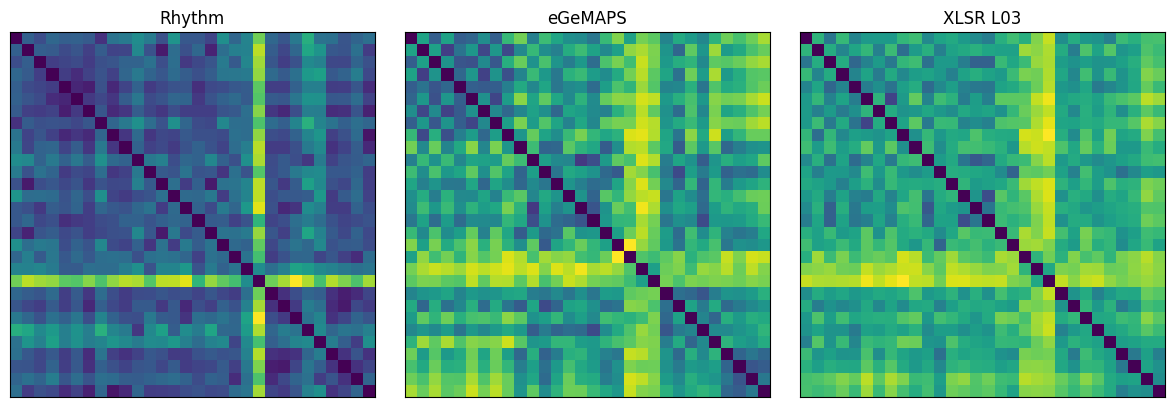

In [51]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

matrices = [
    rhythm_rdm,
    egemaps_rdm,
    xlsr_L03_rdm
]

titles = [
    "Rhythm",
    "eGeMAPS",
    "XLSR L03"
]

for ax, rdm, title in zip(
    axes,
    matrices,
    titles
):
    im = ax.imshow(rdm.values)

    ax.set_title(title)

    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()

plt.show()

Print dimensionality information beside the RSA results

In [40]:
# --------------------------------------------------
# Print full RSA results
# --------------------------------------------------

for name, result in [
    ("Rhythm – eGeMAPS", rsa_rhythm_egemaps),
    ("Rhythm – XLSR L03", rsa_rhythm_xlsr_L03),
    ("eGeMAPS – XLSR L03", rsa_egemaps_xlsr_L03),
]:
    print(name)
    print(f"rho = {result['rho']:.4f}")
    print(f"p   = {result['p']:.6f}")
    print()

Rhythm – eGeMAPS
rho = 0.4455
p   = 0.000100

Rhythm – XLSR L03
rho = 0.4307
p   = 0.000200

eGeMAPS – XLSR L03
rho = 0.8467
p   = 0.000100



# --------------------------------------------------
# Within and betweeen-speaker task dispersion
# --------------------------------------------------

In [53]:
# ==================================================
# WITHIN- AND BETWEEN-SPEAKER VARIABILITY
# ==================================================

import numpy as np
import pandas as pd

from scipy.spatial.distance import mahalanobis


# ==================================================
# 1. Within-speaker task variability
# ==================================================

def within_speaker_dispersion(
    df,
    pca_result,
    speaker_col,
    task_col,
    k=None
):
    """
    Quantify within-speaker task variability as the mean
    Euclidean distance of a speaker's seven task recordings
    from that speaker's centroid in the retained PCA space.
    """

    # Use all retained PCA components by default
    if k is None:
        k = pca_result["n_retained"]

    # Retained PCA scores
    scores = (
        pca_result["scores"]
        .iloc[:, :k]
        .to_numpy()
    )

    score_cols = [
        f"PC{i+1}"
        for i in range(k)
    ]

    score_df = pd.DataFrame(
        scores,
        columns=score_cols
    )

    score_df["speaker_id"] = (
        df[speaker_col].values
    )

    score_df["task"] = (
        df[task_col].values
    )

    # --------------------------------------------------
    # Speaker-specific centroids
    # --------------------------------------------------

    speaker_centroids = (
        score_df
        .groupby("speaker_id")[score_cols]
        .transform("mean")
    )

    # Difference between each recording and
    # its speaker-specific centroid
    deviations = (
        score_df[score_cols]
        - speaker_centroids
    )

    # Euclidean distance from speaker centroid
    score_df["within_distance"] = np.sqrt(
        np.sum(
            deviations.to_numpy() ** 2,
            axis=1
        )
    )

    # --------------------------------------------------
    # Speaker-level within-speaker variability
    # --------------------------------------------------

    speaker_summary = (
        score_df
        .groupby("speaker_id")["within_distance"]
        .agg(
            mean_within_distance="mean",
            median_within_distance="median",
            sd_within_distance="std",
            min_within_distance="min",
            max_within_distance="max"
        )
        .reset_index()
    )

    # Rank 1 = greatest within-speaker variability
    speaker_summary["within_rank"] = (
        speaker_summary["mean_within_distance"]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )

    speaker_summary = (
        speaker_summary
        .sort_values("within_rank")
        .reset_index(drop=True)
    )

    return score_df, speaker_summary


# --------------------------------------------------
# Run within-speaker analysis: Rhythm
# --------------------------------------------------

rhythm_within, rhythm_speaker_within = (
    within_speaker_dispersion(
        df=df_rhythm,
        pca_result=rhythm_pca,
        speaker_col="speaker_id",
        task_col="Task"
    )
)


# --------------------------------------------------
# Run within-speaker analysis: eGeMAPS
# --------------------------------------------------

egemaps_within, egemaps_speaker_within = (
    within_speaker_dispersion(
        df=df_egemaps,
        pca_result=egemaps_pca,
        speaker_col="speaker_id",
        task_col="task"
    )
)


# --------------------------------------------------
# Run within-speaker analysis: XLSR L03
# --------------------------------------------------

xlsr_L03_within, xlsr_L03_speaker_within = (
    within_speaker_dispersion(
        df=df_xlsr_L03,
        pca_result=xlsr_L03_pca,
        speaker_col="speaker_id",
        task_col="task"
    )
)


# --------------------------------------------------
# Print within-speaker results
# --------------------------------------------------

print("\nRhythm within-speaker task variability")
print(
    rhythm_speaker_within
    .round(3)
)

print("\neGeMAPS within-speaker task variability")
print(
    egemaps_speaker_within
    .round(3)
)

print("\nXLSR L03 within-speaker task variability")
print(
    xlsr_L03_speaker_within
    .round(3)
)


# ==================================================
# 2. Between-speaker differentiation
# ==================================================

def between_speaker_peripherality(
    df,
    pca_result,
    speaker_col,
    task_col,
    k=None
):
    """
    Quantify between-speaker differentiation using
    task-conditioned Mahalanobis distance.

    Each recording is compared with the population centroid
    for the corresponding speaking task. A common covariance
    matrix is estimated from all task-centered observations.
    """

    # Use all retained PCA components by default
    if k is None:
        k = pca_result["n_retained"]

    # Retained PCA scores
    scores = (
        pca_result["scores"]
        .iloc[:, :k]
        .to_numpy()
    )

    score_cols = [
        f"PC{i+1}"
        for i in range(k)
    ]

    score_df = pd.DataFrame(
        scores,
        columns=score_cols
    )

    score_df["speaker_id"] = (
        df[speaker_col].values
    )

    score_df["task"] = (
        df[task_col].values
    )

    # --------------------------------------------------
    # Task-specific population centroids
    # --------------------------------------------------

    task_centroids = (
        score_df
        .groupby("task")[score_cols]
        .transform("mean")
    )

    # Center each recording on the centroid
    # of its corresponding task
    centered_scores = (
        score_df[score_cols]
        - task_centroids
    )

    # --------------------------------------------------
    # Common covariance matrix
    # --------------------------------------------------

    covariance = np.cov(
        centered_scores.to_numpy(),
        rowvar=False
    )

    # Pseudoinverse for possible near-singularity
    inverse_covariance = np.linalg.pinv(
        covariance
    )

    # --------------------------------------------------
    # Task-conditioned Mahalanobis distance
    # --------------------------------------------------

    # After task centering, the task-specific
    # population centroid is the zero vector
    zero = np.zeros(k)

    score_df["between_distance"] = [
        mahalanobis(
            row,
            zero,
            inverse_covariance
        )
        for row in centered_scores.to_numpy()
    ]

    # --------------------------------------------------
    # Speaker-level between-speaker peripherality
    # --------------------------------------------------

    speaker_summary = (
        score_df
        .groupby("speaker_id")["between_distance"]
        .agg(
            mean_between_distance="mean",
            median_between_distance="median",
            sd_between_distance="std",
            min_between_distance="min",
            max_between_distance="max"
        )
        .reset_index()
    )

    # Rank 1 = most peripheral speaker
    speaker_summary["between_rank"] = (
        speaker_summary["mean_between_distance"]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )

    speaker_summary = (
        speaker_summary
        .sort_values("between_rank")
        .reset_index(drop=True)
    )

    return score_df, speaker_summary


# --------------------------------------------------
# Run between-speaker analysis: Rhythm
# --------------------------------------------------

rhythm_between, rhythm_speaker_between = (
    between_speaker_peripherality(
        df=df_rhythm,
        pca_result=rhythm_pca,
        speaker_col="speaker_id",
        task_col="Task"
    )
)


# --------------------------------------------------
# Run between-speaker analysis: eGeMAPS
# --------------------------------------------------

egemaps_between, egemaps_speaker_between = (
    between_speaker_peripherality(
        df=df_egemaps,
        pca_result=egemaps_pca,
        speaker_col="speaker_id",
        task_col="task"
    )
)


# --------------------------------------------------
# Run between-speaker analysis: XLSR L03
# --------------------------------------------------

xlsr_L03_between, xlsr_L03_speaker_between = (
    between_speaker_peripherality(
        df=df_xlsr_L03,
        pca_result=xlsr_L03_pca,
        speaker_col="speaker_id",
        task_col="task"
    )
)


# --------------------------------------------------
# Print between-speaker results
# --------------------------------------------------

print("\nRhythm between-speaker peripherality")
print(
    rhythm_speaker_between
    .round(3)
)

print("\neGeMAPS between-speaker peripherality")
print(
    egemaps_speaker_between
    .round(3)
)

print("\nXLSR L03 between-speaker peripherality")
print(
    xlsr_L03_speaker_between
    .round(3)
)


# ==================================================
# 3. Quick check
# ==================================================

print("\n" + "=" * 55)
print("PCA DIMENSIONS USED IN THESE ANALYSES")
print("=" * 55)

print(
    f"Rhythm:   {rhythm_pca['n_retained']} PCs "
    f"({rhythm_pca['explained_variance'] * 100:.1f}% variance)"
)

print(
    f"eGeMAPS:  {egemaps_pca['n_retained']} PCs "
    f"({egemaps_pca['explained_variance'] * 100:.1f}% variance)"
)

print(
    f"XLSR L03: {xlsr_L03_pca['n_retained']} PCs "
    f"({xlsr_L03_pca['explained_variance'] * 100:.1f}% variance)"
)

print("\nNumber of speakers")
print("------------------")
print(
    "Rhythm:  ",
    len(rhythm_speaker_within)
)
print(
    "eGeMAPS: ",
    len(egemaps_speaker_within)
)
print(
    "XLSR L03:",
    len(xlsr_L03_speaker_within)
)


Rhythm within-speaker task variability
   speaker_id  mean_within_distance  median_within_distance  \
0         P12                 3.856                   4.734   
1         P30                 3.571                   3.251   
2         P11                 3.250                   3.417   
3         P20                 3.150                   3.592   
4         P16                 3.147                   3.925   
5         P22                 3.037                   3.089   
6         P14                 3.005                   2.643   
7         P18                 2.925                   2.968   
8         P29                 2.839                   3.061   
9         P02                 2.837                   3.091   
10        P21                 2.783                   2.224   
11        P24                 2.749                   2.769   
12        P05                 2.710                   2.820   
13        P08                 2.702                   2.590   
14        P25  

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.

# ==================================================
# CROSS-REPRESENTATION STATISTICAL ANALYSIS (hand-crafted features)
# ==================================================

In [54]:


from scipy.stats import spearmanr
import numpy as np
import pandas as pd


def compare_representations(
    rhythm_summary,
    egemaps_summary,
    value_col,
    rank_col,
    n_permutations=10_000,
    n_bootstrap=10_000,
    seed=42
):
    """
    Compare speaker-level values between rhythm and eGeMAPS.

    Returns:
        comparison_df
        results dictionary containing:
            Spearman rho
            permutation p-value
            bootstrap 95% CI
    """

    # --------------------------------------------------
    # Merge speakers across representations
    # --------------------------------------------------

    comparison = (
        rhythm_summary[
            ["speaker_id", value_col, rank_col]
        ]
        .rename(columns={
            value_col: "rhythm_value",
            rank_col: "rhythm_rank"
        })
        .merge(
            egemaps_summary[
                ["speaker_id", value_col, rank_col]
            ].rename(columns={
                value_col: "egemaps_value",
                rank_col: "egemaps_rank"
            }),
            on="speaker_id"
        )
    )

    x = comparison["rhythm_value"].to_numpy()
    y = comparison["egemaps_value"].to_numpy()

    # --------------------------------------------------
    # Observed Spearman correlation
    # --------------------------------------------------

    rho = spearmanr(x, y).statistic

    # --------------------------------------------------
    # Permutation test
    # --------------------------------------------------

    rng = np.random.default_rng(seed)

    permuted_rhos = np.empty(n_permutations)

    for i in range(n_permutations):
        permuted_rhos[i] = spearmanr(
            x,
            rng.permutation(y)
        ).statistic

    permutation_p = (
        np.sum(
            np.abs(permuted_rhos) >= np.abs(rho)
        ) + 1
    ) / (n_permutations + 1)

    # --------------------------------------------------
    # Speaker-level bootstrap confidence interval
    # --------------------------------------------------

    rng_boot = np.random.default_rng(seed)

    n_speakers = len(comparison)
    bootstrap_rhos = []

    for i in range(n_bootstrap):

        idx = rng_boot.choice(
            n_speakers,
            size=n_speakers,
            replace=True
        )

        x_boot = x[idx]
        y_boot = y[idx]

        # Avoid undefined Spearman correlations
        if (
            len(np.unique(x_boot)) > 1
            and len(np.unique(y_boot)) > 1
        ):
            bootstrap_rhos.append(
                spearmanr(
                    x_boot,
                    y_boot
                ).statistic
            )

    bootstrap_rhos = np.asarray(
        bootstrap_rhos
    )

    ci_low, ci_high = np.percentile(
        bootstrap_rhos,
        [2.5, 97.5]
    )

    results = {
        "rho": rho,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "permutation_p": permutation_p
    }

    return comparison, results


# ==================================================
# 1. Within-speaker variability:
#    rhythm vs eGeMAPS
# ==================================================

within_comparison, within_stats = (
    compare_representations(
        rhythm_summary=rhythm_speaker_within,
        egemaps_summary=egemaps_speaker_within,
        value_col="mean_within_distance",
        rank_col="within_rank"
    )
)


print("\nWITHIN-SPEAKER VARIABILITY")
print(
    f"Spearman rho = "
    f"{within_stats['rho']:.3f}"
)

print(
    f"95% bootstrap CI = "
    f"[{within_stats['ci_low']:.3f}, "
    f"{within_stats['ci_high']:.3f}]"
)

print(
    f"Permutation p = "
    f"{within_stats['permutation_p']:.4f}"
)


# ==================================================
# 2. Between-speaker peripherality:
#    rhythm vs eGeMAPS
# ==================================================

between_comparison, between_stats = (
    compare_representations(
        rhythm_summary=rhythm_speaker_between,
        egemaps_summary=egemaps_speaker_between,
        value_col="mean_between_distance",
        rank_col="between_rank"
    )
)


print("\nBETWEEN-SPEAKER PERIPHERALITY")
print(
    f"Spearman rho = "
    f"{between_stats['rho']:.3f}"
)

print(
    f"95% bootstrap CI = "
    f"[{between_stats['ci_low']:.3f}, "
    f"{between_stats['ci_high']:.3f}]"
)

print(
    f"Permutation p = "
    f"{between_stats['permutation_p']:.4f}"
)


WITHIN-SPEAKER VARIABILITY
Spearman rho = 0.260
95% bootstrap CI = [-0.121, 0.577]
Permutation p = 0.1607

BETWEEN-SPEAKER PERIPHERALITY
Spearman rho = 0.312
95% bootstrap CI = [-0.099, 0.641]
Permutation p = 0.0968


In [55]:
# ==================================================
# Summary table
# ==================================================

summary_stats = pd.DataFrame({
    "Measure": [
        "Within-speaker task variability",
        "Between-speaker peripherality"
    ],
    "Spearman_rho": [
        within_stats["rho"],
        between_stats["rho"]
    ],
    "CI_low": [
        within_stats["ci_low"],
        between_stats["ci_low"]
    ],
    "CI_high": [
        within_stats["ci_high"],
        between_stats["ci_high"]
    ],
    "Permutation_p": [
        within_stats["permutation_p"],
        between_stats["permutation_p"]
    ]
})

print(
    summary_stats.round(3).to_string(index=False)
)

                        Measure  Spearman_rho  CI_low  CI_high  Permutation_p
Within-speaker task variability         0.260  -0.121    0.577          0.161
  Between-speaker peripherality         0.312  -0.099    0.641          0.097


In [56]:
# ==================================================
# Rank-comparison plotting function
# ==================================================

import matplotlib.pyplot as plt


def plot_rank_comparison(
    comparison,
    xlabel,
    ylabel,
    title=None,
    save_path=None
):
    fig, ax = plt.subplots(
        figsize=(5, 5)
    )

    ax.scatter(
        comparison["rhythm_rank"],
        comparison["egemaps_rank"],
        s=35
    )

    # Identical-rank reference line
    ax.plot(
        [1, 30],
        [1, 30],
        linestyle="--",
        linewidth=0.8
    )

    # Speaker labels
    for _, row in comparison.iterrows():
        ax.annotate(
            row["speaker_id"],
            (
                row["rhythm_rank"],
                row["egemaps_rank"]
            ),
            fontsize=7,
            xytext=(3, 3),
            textcoords="offset points"
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Rank 1 = highest variability/peripherality
    ax.set_xlim(30.5, 0.5)
    ax.set_ylim(30.5, 0.5)

    ax.set_xticks(
        [30, 25, 20, 15, 10, 5, 1]
    )

    ax.set_yticks(
        [30, 25, 20, 15, 10, 5, 1]
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    if title is not None:
        ax.set_title(title)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            bbox_inches="tight"
        )

    plt.show()

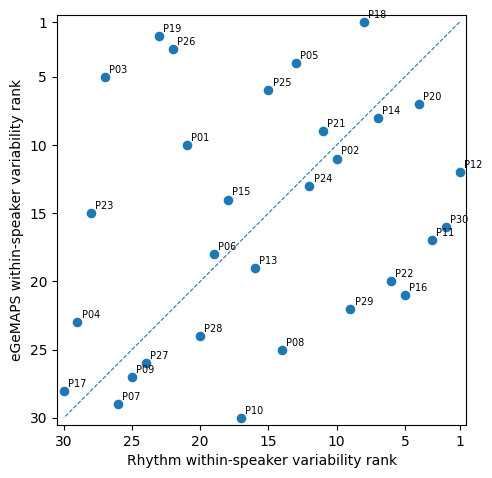

In [57]:
# ==================================================
# Within-speaker rank comparison
# ==================================================

plot_rank_comparison(
    comparison=within_comparison,
    xlabel="Rhythm within-speaker variability rank",
    ylabel="eGeMAPS within-speaker variability rank",
    save_path="within_speaker_rank_comparison.pdf"
)

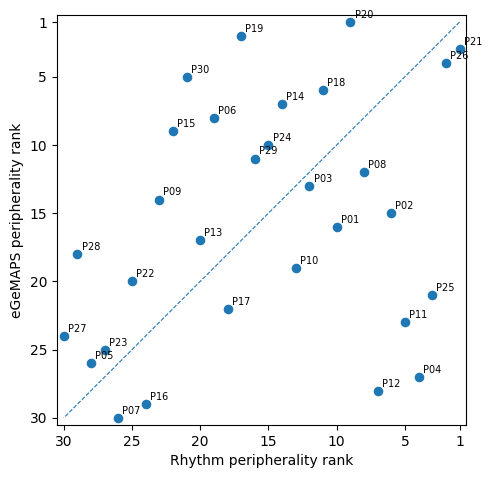

In [58]:
# ==================================================
# Between-speaker rank comparison
# ==================================================

plot_rank_comparison(
    comparison=between_comparison,
    xlabel="Rhythm peripherality rank",
    ylabel="eGeMAPS peripherality rank",
    save_path="between_speaker_rank_comparison.pdf"
)

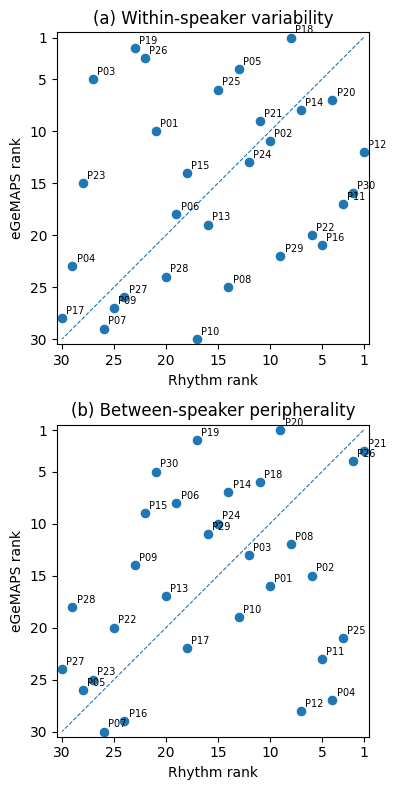

In [59]:
# ==================================================
# Combined within/between rank figure — vertical
# ==================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(5, 8)
)


# --------------------------------------------------
# Panel A: within-speaker variability
# --------------------------------------------------

ax = axes[0]

ax.scatter(
    within_comparison["rhythm_rank"],
    within_comparison["egemaps_rank"],
    s=35
)

ax.plot(
    [1, 30],
    [1, 30],
    linestyle="--",
    linewidth=0.8
)

for _, row in within_comparison.iterrows():
    ax.annotate(
        row["speaker_id"],
        (
            row["rhythm_rank"],
            row["egemaps_rank"]
        ),
        fontsize=7,
        xytext=(3, 3),
        textcoords="offset points"
    )

ax.set_xlabel("Rhythm rank")
ax.set_ylabel("eGeMAPS rank")
ax.set_title("(a) Within-speaker variability")

# Rank 1 = greatest variability
ax.set_xlim(30.5, 0.5)
ax.set_ylim(30.5, 0.5)

ax.set_xticks([30, 25, 20, 15, 10, 5, 1])
ax.set_yticks([30, 25, 20, 15, 10, 5, 1])

ax.set_aspect(
    "equal",
    adjustable="box"
)


# --------------------------------------------------
# Panel B: between-speaker peripherality
# --------------------------------------------------

ax = axes[1]

ax.scatter(
    between_comparison["rhythm_rank"],
    between_comparison["egemaps_rank"],
    s=35
)

ax.plot(
    [1, 30],
    [1, 30],
    linestyle="--",
    linewidth=0.8
)

for _, row in between_comparison.iterrows():
    ax.annotate(
        row["speaker_id"],
        (
            row["rhythm_rank"],
            row["egemaps_rank"]
        ),
        fontsize=7,
        xytext=(3, 3),
        textcoords="offset points"
    )

ax.set_xlabel("Rhythm rank")
ax.set_ylabel("eGeMAPS rank")
ax.set_title("(b) Between-speaker peripherality")

# Rank 1 = greatest peripherality
ax.set_xlim(30.5, 0.5)
ax.set_ylim(30.5, 0.5)

ax.set_xticks([30, 25, 20, 15, 10, 5, 1])
ax.set_yticks([30, 25, 20, 15, 10, 5, 1])

ax.set_aspect(
    "equal",
    adjustable="box"
)


# --------------------------------------------------
# Save
# --------------------------------------------------

plt.tight_layout()

plt.savefig(
    "within_between_rank_comparison_vertical.pdf",
    bbox_inches="tight"
)

plt.show()